# **Amazon UK Product Analysis - Univariate EDA**

#### **By: Paulina Mamiaga**

----------------

## **1. Objective**

The objective of this analysis is to explore and understand the structure and distribution of product listings on Amazon UK through univariate exploratory data analysis (EDA).

This study focuses on key product attributes such as category, price, and customer ratings in order to:

- Identify the most represented product categories and assess market concentration
- Analyze pricing patterns, including central tendencies and variability
- Understand customer rating behavior and detect potential biases or trends

From a business perspective, this analysis aims to provide insights that can support product positioning, pricing strategies, and inventory decisions within a competitive e-commerce environment.

## **2. Part 1: Understanding Product Categories**

In [24]:
# Set up the environment and load the dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


current_dir = os.getcwd()


while not os.path.exists(os.path.join(current_dir, "data", "raw")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/raw not found")
    current_dir = parent


os.chdir(current_dir)

print("Project root:", os.getcwd())
print("data/raw exists:", os.path.exists("data/raw"))


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)



Project root: c:\Users\pauli\OneDrive\Documentos\GitHub\lab-eda-univariate
data/raw exists: True


df = pd.read_csv("data/raw/train_v2.csv")

In [25]:
# Load the dataset

df = pd.read_csv("data/raw/amz_uk_price_prediction_dataset.csv")  # Replace with your actual dataset path

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [26]:
# Check for missing values and duplicates
print("\nMissing:")
print(df.isnull().sum())
print("\nDuplicate products in df:")
print(df["asin"].duplicated().sum())
print("\nUnique products in df:")
print(df["asin"].nunique())



Missing:
uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

Duplicate products in df:
220909

Unique products in df:
2222742


In [27]:
# Check for duplicates using 'uid' instead of 'asin'
print("\nDuplicate products in df:")
print(df["uid"].duplicated().sum())
print("\nUnique products in df:")
print(df["uid"].nunique())


Duplicate products in df:
0

Unique products in df:
2443651


### **2.1.1. Frequency Table**

In [28]:
category_counts = df['category'].value_counts()

category_counts.head(10)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64

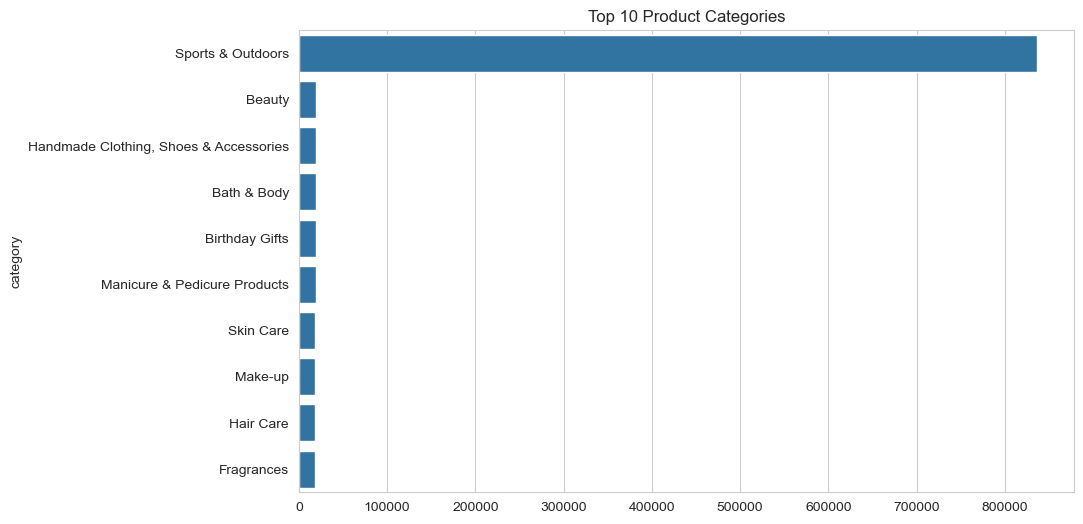

In [33]:
top10 = category_counts.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 Product Categories")
plt.show()

### **2.1.2. Top 5 categories**

In [32]:
# create table withe the top 5 categories and their counts
top5_df = top5.reset_index()
top5_df.columns = ['category', 'count']

print(top5_df)

                                 category   count
0                       Sports & Outdoors  836265
1                                  Beauty   19312
2  Handmade Clothing, Shoes & Accessories   19229
3                             Bath & Body   19092
4                          Birthday Gifts   18978


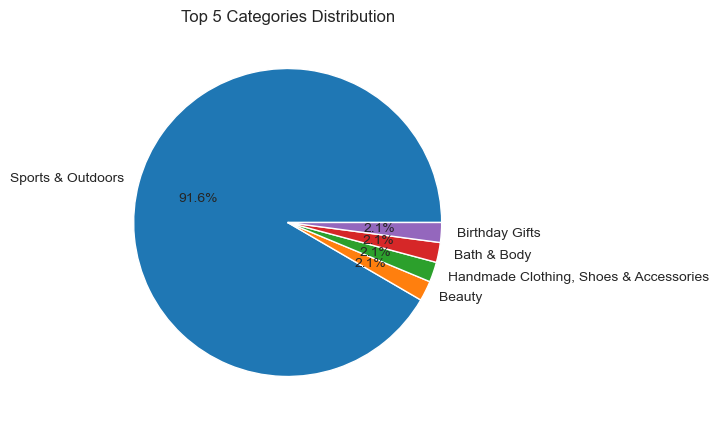

In [34]:
top5.plot.pie(autopct='%1.1f%%')
plt.title("Top 5 Categories Distribution")
plt.ylabel("")
plt.show()

## **3. Part 2: Delving into Product Pricing**

### **3.2.1. Centrality**

Mean Price: 89.24380943923663
Median Price: 19.09
Mode Price: 9.99


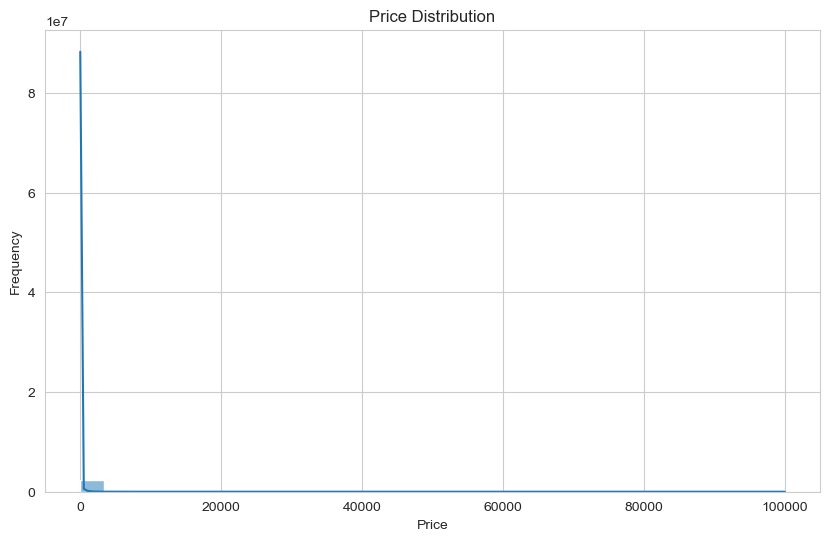

In [36]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

mean_price, median_price, mode_price

print(f"Mean Price: {mean_price}")
print(f"Median Price: {median_price}")
print(f"Mode Price: {mode_price}")

plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


### **3.2.2. Dispersion**

In [38]:
variance = df['price'].var()
std = df['price'].std()
price_range = df['price'].max() - df['price'].min()
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)

variance, std, price_range, iqr

print(f"Variance: {variance}")
print(f"Standard Deviation: {std}")
print(f"Range: {price_range}")
print(f"IQR: {iqr}")
    

Variance: 119445.48532256528
Standard Deviation: 345.60886175352226
Range: 100000.0
IQR: 36.0


### **3.2.3. Histogram**

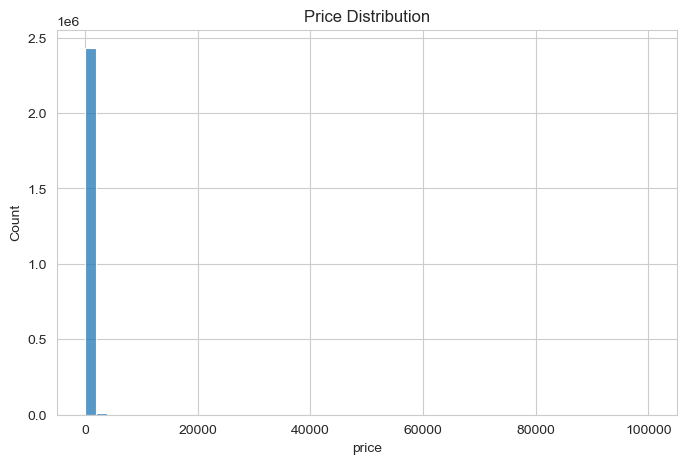

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

### **3.2.4. Boxplot**

<Axes: xlabel='price'>

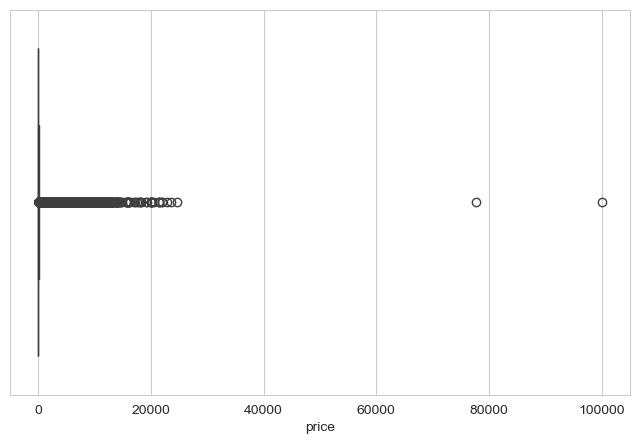

In [45]:
sns.boxplot(x=df['price'])

## **4. Part 3: Unpacking Product Ratings**

### **4.3.1 Centrality**

In [49]:
df['stars'].mean()
df['stars'].median()
df['stars'].mode()

print(f"Mean Stars: {df['stars'].mean()}")
print(f"Median Stars: {df['stars'].median()}")
print(f"Mode Stars: {df['stars'].mode()[0]}")


Mean Stars: 2.152836472966065
Median Stars: 0.0
Mode Stars: 0.0


In [51]:
mean_rating = df['stars'].mean()
median_rating = df['stars'].median()
mode_rating = df['stars'].mode()[0]

mean_rating, median_rating, mode_rating

print(f"Mean Rating: {mean_rating}")
print(f"Median Rating: {median_rating}")
print(f"Mode Rating: {mode_rating}")


Mean Rating: 2.152836472966065
Median Rating: 0.0
Mode Rating: 0.0


### **4.3.2. Dispersion**

In [53]:
df['stars'].std()
df['stars'].var()

iqr_rating = df['stars'].quantile(0.75) - df['stars'].quantile(0.25)

print(f"Standard Deviation of Stars: {df['stars'].std()}")
print(f"Variance of Stars: {df['stars'].var()}")
print(f"IQR of Stars: {iqr_rating}")


Standard Deviation of Stars: 2.1948653785054697
Variance of Stars: 4.81743402976196
IQR of Stars: 4.4


### **3.4.3. Shape**

In [55]:
df['stars'].skew()
df['stars'].kurt()

print(f"Skewness of Stars: {df['stars'].skew()}")


Skewness of Stars: 0.08120735761080985


### **4.3.4. Histogram**

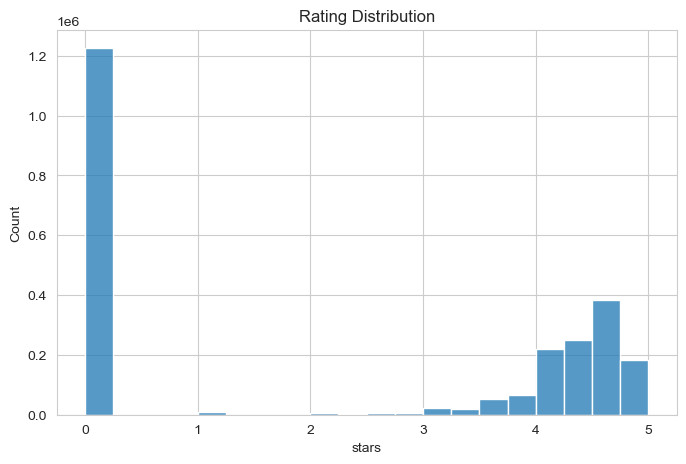

In [56]:
sns.histplot(df['stars'], bins=20)
plt.title("Rating Distribution")
plt.show()

In [57]:
df['stars'].describe()

count    2.443651e+06
mean     2.152836e+00
std      2.194865e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.400000e+00
max      5.000000e+00
Name: stars, dtype: float64